## <b><font color='darkblue'>Preface</font></b>
Sample code to use [**`yfinance`**](https://github.com/ranaroussi/yfinance) to query below information:
- Stock price of certain name or id in Taiwan stock market
- Stocks that increased over 5% today
- Stocks with dividend yield over 5%
- Top gaining Taiwan stocks this week
- Show historical price trend for TSMC

In [2]:
from __future__ import annotations

### <b><font color='darkgreen'>Install packages</font></b>

```bash
$ uv add yfinance
```

In [3]:
!uv pip list | grep yfinance

Using Python 3.12.3 environment at: /mnt/sdb/Gitrepos/finance_agent/.venv
yfinance                  1.3.0


### <b><font color='darkgreen'>Import Libraries</font></b>

In [2]:
import yfinance as yf

## <b><font color='darkblue'>Usages</font></b>
Here we are going to introduce usages of target package.

### <b><font color='darkgreen'>1. Query Stock Price by Taiwan Stock ID</font></b>
Example:
- TSMC → `2330.TW`
- ETF 0050 → `0050.TW`

In [2]:
%%time
symbol = "2330.TW"

ticker = yf.Ticker(symbol)

CPU times: user 816 μs, sys: 550 μs, total: 1.37 ms
Wall time: 1.31 ms


In [14]:
# Get latest market price
info = ticker.info

print("Symbol:", symbol)
print("Company:", info.get("longName"))
print("Current Price:", info.get("currentPrice"))
print("Previous Close:", info.get("previousClose"))
print("Market Cap:", info.get("marketCap"))

Symbol: 2330.TW
Company: Taiwan Semiconductor Manufacturing Company Limited
Current Price: 2290.0
Previous Close: 2310.0
Market Cap: 59384277237760


### <b><font color='darkgreen'>2. Find Stocks That Increased Over 5% Today</font></b>
Yahoo Finance does not provide all Taiwan stocks automatically. You usually need a predefined Taiwan stock list.

Example stock list:

In [15]:
taiwan_stocks = [
  "2330.TW",  # TSMC
  "2317.TW",  # Hon Hai
  "2454.TW",  # MediaTek
  "2303.TW",  # UMC
  "0050.TW",  # ETF
]

In [16]:
results = []

for symbol in taiwan_stocks:
  try:
    ticker = yf.Ticker(symbol)
    info = ticker.info

    current_price = info.get("currentPrice")
    prev_close = info.get("previousClose")

    if current_price and prev_close:
      increase_pct = ((current_price - prev_close) / prev_close) * 100

      if increase_pct > 5:
        results.append({"symbol": symbol, "increase_pct": round(increase_pct, 2)})

  except Exception as e:
    print(f"Error processing {symbol}: {e}")

print("Stocks increased over 5% today:")

for r in results:
  print(r)

Stocks increased over 5% today:
{'symbol': '2454.TW', 'increase_pct': 6.14}


### <b><font color='darkgreen'>3. Find Stocks With Dividend Yield Over 5%</font></b>
[**`Dividend Yield`**](https://zh.wikipedia.org/zh-tw/%E7%8F%BE%E9%87%91%E6%AE%96%E5%88%A9%E7%8E%87) (殖利率)
> 現金殖利率（英語：Dividend yield）的定義是 [**每股股利**](https://zh.wikipedia.org/wiki/%E8%82%A1%E6%81%AF)（現金股利）除以 [**每股股價**]( https://zh.wikipedia.org/wiki/%E8%82%A1%E5%83%B9)，通常以百分比表示。
> 
> 例：現金股利為1元，股價20元，則現金殖利率為5%；若來年配息仍為1元，股價已至25元，則現金殖利率降為4%。
> 
> 若股票的現金殖利率大於 [**定期存款**](https://zh.wikipedia.org/wiki/%E5%AE%9A%E6%9C%9F%E5%AD%98%E6%AC%BE) 的利率，一般會稱為 [**定存概念股**](https://zh.wikipedia.org/zh-tw/%E7%8F%BE%E9%87%91%E6%AE%96%E5%88%A9%E7%8E%87#cite_note-%E5%AD%AB%E4%BC%8A%E5%BB%B72011-3)。

In [19]:
symbol = "2330.TW"

ticker = yf.Ticker(symbol)

info = ticker.info

current_price = info.get("currentPrice")

# Annual dividend per share
annual_dividend = info.get("dividendRate")

print("Current Price:", current_price)
print("Annual Dividend:", annual_dividend)

if current_price and annual_dividend:
  dividend_yield = (annual_dividend / current_price) * 100

  print(f"Calculated Dividend Yield: {dividend_yield:.2f}%")

Current Price: 2290.0
Annual Dividend: 24.0
Calculated Dividend Yield: 1.05%


### <b><font color='darkgreen'>4. Find Top Gaining Taiwan Stocks This Week</font></b>
his example calculates 7-day return:

In [21]:
taiwan_stocks = ["2330.TW", "2317.TW", "2454.TW", "2303.TW", "0050.TW"]

results = []

for symbol in taiwan_stocks:
  try:
    ticker = yf.Ticker(symbol)

    hist = ticker.history(period="7d")

    if len(hist) >= 2:
      start_price = hist["Close"].iloc[0]
      end_price = hist["Close"].iloc[-1]

      weekly_return = ((end_price - start_price) / start_price) * 100

      results.append(
        {"symbol": symbol, "weekly_return_pct": float(round(weekly_return, 2))}
      )

  except Exception as e:
    print(f"Error processing {symbol}: {e}")

# Sort descending
results = sorted(results, key=lambda x: x["weekly_return_pct"], reverse=True)

print("Top gaining Taiwan stocks this week:")

for r in results:
  print(r)

Top gaining Taiwan stocks this week:
{'symbol': '2454.TW', 'weekly_return_pct': 40.97}
{'symbol': '2303.TW', 'weekly_return_pct': 22.55}
{'symbol': '2317.TW', 'weekly_return_pct': 11.11}
{'symbol': '0050.TW', 'weekly_return_pct': 6.89}
{'symbol': '2330.TW', 'weekly_return_pct': 5.05}


### <b><font color='darkgreen'>5. Show Historical Price Trend for TSMC</font></b>
Example using `pandas` plotting.

                                 Open        High         Low       Close  \
Date                                                                        
2025-05-08 00:00:00+08:00  919.282699  925.194485  904.503235  904.503235   
2025-05-09 00:00:00+08:00  924.209151  935.047424  920.267960  935.047424   
2025-05-12 00:00:00+08:00  939.973978  947.856359  938.003382  942.929871   
2025-05-13 00:00:00+08:00  975.444669  975.444669  954.753418  954.753418   
2025-05-14 00:00:00+08:00  975.444699  984.312378  973.474103  984.312378   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-05-08 00:00:00+08:00  27985917        0.0           0.0  
2025-05-09 00:00:00+08:00  36383573        0.0           0.0  
2025-05-12 00:00:00+08:00  23402547        0.0           0.0  
2025-05-13 00:00:00+08:00  38047856        0.0           0.0  
2025-05-14 00:00:00+08:00  40475123        0.0           0.0  


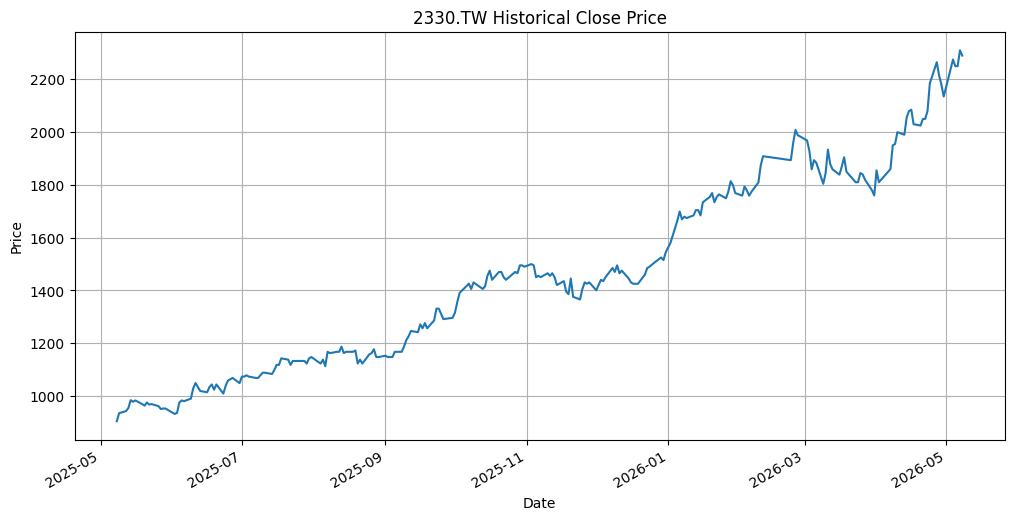

In [23]:
import yfinance as yf
import matplotlib.pyplot as plt

symbol = "2330.TW"

ticker = yf.Ticker(symbol)

# 1 year history
hist = ticker.history(period="1y")

print(hist.head())

# Plot close price trend
hist["Close"].plot(figsize=(12, 6), title=f"{symbol} Historical Close Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

### <b><font color='darkgreen'>6. Recommended Improvement for Your Agent</font></b>
Instead of directly calling `ticker.info` repeatedly, you should:

- Cache stock metadata locally
- Cache historical prices into SQLite/PostgreSQL
- Run screening queries against local DB
- Use `yfinance` only for synchronization

This design will:

- Improve performance
- Reduce Yahoo Finance requests
- Avoid rate limiting
- Make analytics much faster

### <b><font color='darkgreen'>7. Suggested Helper Wrapper</font></b>
You can encapsulate `yfinance` into your provider layer.

Example:

In [24]:
import yfinance as yf


class YahooFinanceProvider:
  def get_stock_info(self, symbol: str):
    ticker = yf.Ticker(symbol)
    return ticker.info

  def get_history(self, symbol: str, period: str = "1y"):
    ticker = yf.Ticker(symbol)
    return ticker.history(period=period)

Usage:

In [25]:
provider = YahooFinanceProvider()

hist = provider.get_history("2330.TW")

print(hist.tail())

                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-05-04 00:00:00+08:00  2200.0  2285.0  2195.0  2275.0  38390062   
2026-05-05 00:00:00+08:00  2250.0  2270.0  2240.0  2250.0  21625279   
2026-05-06 00:00:00+08:00  2250.0  2285.0  2240.0  2250.0  31918664   
2026-05-07 00:00:00+08:00  2335.0  2345.0  2310.0  2310.0  35034517   
2026-05-08 00:00:00+08:00  2300.0  2310.0  2265.0  2290.0  27102571   

                           Dividends  Stock Splits  
Date                                                
2026-05-04 00:00:00+08:00        0.0           0.0  
2026-05-05 00:00:00+08:00        0.0           0.0  
2026-05-06 00:00:00+08:00        0.0           0.0  
2026-05-07 00:00:00+08:00        0.0           0.0  
2026-05-08 00:00:00+08:00        0.0           0.0  


### <b><font color='darkgreen'>8. Recommended Next Step</font></b>
For your `finance_agent`, the next recommended implementation order is:

1. Build provider abstraction
2. Build SQLite schema
3. Implement sync service
4. Implement screening queries
5. Add ADK tools
6. Add natural language intent parsing
7. Add LLM reasoning

### <b><font color='darkgreen'>9. Get ROE (Return of Entity)</font></b>
[**Wantgoo - ROE(股東權益報酬率)**](https://www.wantgoo.com/stock/9940/profitability/roe-roa)
>  **公式：單季季稅後淨利 / 期初和期末股東權益平均**. ROE(股東權益報酬率)衡量：企業為整體股東資金創造獲利的效率。 股東權益報酬率越高，代表公司為股東賺回的獲利越高。 股神巴菲特持有的公司都具有高ROE特色(高於10~15%)， 如其走勢平穩或上升，代表為股東帶來獲利的效率越來越好。


Take [**`信義(9940)`**](https://www.wantgoo.com/stock/9940/profitability/roe-roa) for example:

#### <b> By `yfinance` package</b>

In [3]:
%%time
symbol = "9940.TW"

ticker = yf.Ticker(symbol)

CPU times: user 376 μs, sys: 2.96 ms, total: 3.34 ms
Wall time: 3.29 ms


In [6]:
roe = ticker.info.get("returnOnEquity")

In [7]:
print(f"Symtol {symbol} has ROE as {roe:.01%}")

Symtol 9940.TW has ROE as 2.1%


#### <b>By crawler on page `https://www.wantgoo.com/stock/9940/profitability/roe-roa`</b>

Need to install
```bash
$ playwright install
```

In [18]:
import pandas as pd
from pathlib import Path

CACHE_DIR = Path.home() / ".financial_stock_agent" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ROE_CACHE_DIR = Path.home() / ".financial_stock_agent" / "cache" / "roe"
ROE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
print(ROE_CACHE_DIR)

/root/.financial_stock_agent/cache/roe


In [58]:
import re
from datetime import datetime, timedelta
from pathlib import Path

from playwright.async_api import async_playwright


class WantGooROEProvider:
  CACHE_TTL = timedelta(days=1)

  def __init__(self):
    self.cache_dir = Path.home() / ".financial_stock_agent" / "cache" / "roe"
    self.cache_dir.mkdir(parents=True, exist_ok=True)

  # =========================
  # PUBLIC API
  # =========================

  async def get_roe(self, symbol: str | int, year: int, q: int) -> float:
    stock_id = str(symbol)

    df = await self._get_dataframe(stock_id)

    match = df[(df["year"] == year) & (df["quarter"] == q)]

    if match.empty:
      raise ValueError(f"ROE not found: {stock_id} {year}Q{q}")

    return float(match.iloc[0]["roe"])

  async def get_latest_roe(self, symbol: str | int) -> float:
    stock_id = str(symbol)
    df = await self._get_dataframe(stock_id)
    return float(df.iloc[0]["roe"])

  # =========================
  # CORE LOGIC
  # =========================

  async def _get_dataframe(self, stock_id: str) -> pd.DataFrame:
    cache_path = self.cache_dir / f"{stock_id}.csv"

    cached = self._load_cache(cache_path)

    if cached is not None and not self._cache_expired(cache_path):
      return cached

    latest = await self._crawl(stock_id)

    merged, changed = self._merge(cached, latest)

    if changed:
      self._save(cache_path, merged)

    return merged

  # =========================
  # JS RENDERED CRAWLER
  # =========================

  async def _crawl(self, stock_id: str) -> pd.DataFrame:
    url = f"https://www.wantgoo.com/stock/{stock_id}/profitability/roe-roa"

    html = await self._fetch_rendered_html(url)

    # extract rows from tbody
    rows = re.findall(
      r"<tr.*?>(.*?)</tr>",
      html,
      re.S,
    )

    data = []

    for row in rows:
      cols = re.findall(r"<td.*?>(.*?)</td>", row)

      if len(cols) != 4:
        continue

      period = self._clean(cols[0])
      if not re.match(r"\d{4}Q[1-4]", period):
        continue

      year = int(period[:4])
      quarter = int(period[-1])

      roe = float(self._clean(cols[1]))
      roa = float(self._clean(cols[2]))
      price = float(self._clean(cols[3]))

      data.append((year, quarter, roe, roa, price))

    if not data:
      raise RuntimeError("Failed to parse ROE table")

    return pd.DataFrame(
      data,
      columns=["year", "quarter", "roe", "roa", "price"],
    )

  async def _fetch_rendered_html(self, url: str) -> str:
    """Fetches a JavaScript-rendered HTML page.

    Args:
        url: Target URL.

    Returns:
        Fully rendered HTML after JavaScript execution.
    """
    async with async_playwright() as playwright:
      browser = await playwright.chromium.launch(
        headless=True,
      )

      context = await browser.new_context(
        locale="zh-TW",
        timezone_id="Asia/Taipei",
        viewport={
          "width": 1600,
          "height": 1200,
        },
        user_agent=(
          "Mozilla/5.0 "
          "(Windows NT 10.0; Win64; x64) "
          "AppleWebKit/537.36 "
          "(KHTML, like Gecko) "
          "Chrome/138.0.0.0 "
          "Safari/537.36"
        ),
      )

      await context.set_extra_http_headers(
        {
          "Accept-Language": "zh-TW,zh;q=0.9,en;q=0.8",
        }
      )

      page = await context.new_page()

      # ------------------------------------------------------------------
      # Debug network traffic
      # ------------------------------------------------------------------

      page.on(
        "response",
        lambda response: print(
          f"{response.status:3d} {response.request.resource_type:8s} {response.url}"
        ),
      )

      # ------------------------------------------------------------------
      # Navigate
      # ------------------------------------------------------------------

      await page.goto(
        url,
        wait_until="domcontentloaded",
        timeout=60000,
      )

      #
      # Give the frontend time to finish rendering.
      #
      await page.wait_for_timeout(5000)

      # ------------------------------------------------------------------
      # Debug information
      # ------------------------------------------------------------------

      print("Title:", await page.title())
      print("URL:", page.url)

      print("Frames:")
      for frame in page.frames:
        print("   ", frame.url)

      print(
        "Tables:",
        await page.locator("table").count(),
      )

      print(
        "Rows:",
        await page.locator("table tbody tr").count(),
      )

      # ------------------------------------------------------------------
      # Save rendered page for inspection
      # ------------------------------------------------------------------

      html = await page.content()

      Path("wantgoo_rendered.html").write_text(
        html,
        encoding="utf-8",
      )

      await page.screenshot(
        path="wantgoo_rendered.png",
        full_page=True,
      )

      await browser.close()

      print(f"HTML:\n{html}\n")
      return html

  # =========================
  # CACHE HELPERS
  # =========================

  def _load_cache(self, path: Path) -> pd.DataFrame | None:
    if not path.exists():
      return None
    return pd.read_csv(path)

  def _save(self, path: Path, df: pd.DataFrame) -> None:
    df.to_csv(path, index=False)

  def _cache_expired(self, path: Path) -> bool:
    if not path.exists():
      return True

    modified = datetime.fromtimestamp(path.stat().st_mtime)
    return datetime.now() - modified > self.CACHE_TTL

  # =========================
  # MERGE LOGIC
  # =========================

  def _merge(
    self,
    cached: pd.DataFrame | None,
    latest: pd.DataFrame,
  ) -> tuple[pd.DataFrame, bool]:

    if cached is None:
      return (
        latest.sort_values(
          ["year", "quarter"],
          ascending=False,
        ).reset_index(drop=True),
        True,
      )

    cached = cached.set_index(["year", "quarter"])
    latest = latest.set_index(["year", "quarter"])

    cached.update(latest)

    merged = pd.concat(
      [
        cached,
        latest.loc[~latest.index.isin(cached.index)],
      ]
    )

    merged = merged.sort_index(ascending=False).reset_index()

    changed = not merged.equals(
      cached.reset_index()
      .sort_values(
        ["year", "quarter"],
        ascending=False,
      )
      .reset_index(drop=True)
    )

    return merged, changed

  # =========================
  # UTIL
  # =========================

  def _clean(self, text: str) -> str:
    return re.sub(r"<.*?>", "", text).strip()

In [59]:
wgr = WantGooROEProvider()
df = await wgr._get_dataframe(9940)

200 document https://www.wantgoo.com/stock/9940/profitability/roe-roa
200 stylesheet https://www.wantgoo.com/lib/flipdown/0.3.2/flipdown.min.css
200 stylesheet https://www.wantgoo.com/lib/dragula/dragula.css
200 stylesheet https://www.wantgoo.com/css/_main-layout.min.css?v=AHIu7UgWmHBayJGhFMiyu5AQZLaWHgYz89ogO0AY_ZI
200 stylesheet https://www.wantgoo.com/css/stock/_stock-layout.min.css?v=j2nYM7R8UHi-H1RECfAyjMX0Q-rp9VyWvaLjiFyObGU
200 script   https://www.wantgoo.com/lib/crypto-js/4.1.0/core.min.js
200 script   https://www.wantgoo.com/lib/fingerprintjs/3.3.0/fp.min.js
200 script   https://www.wantgoo.com/lib/dayjs/1.11.1/dayjs.min.js
200 script   https://www.wantgoo.com/lib/crypto-js/4.1.0/md5.min.js
200 script   https://www.wantgoo.com/lib/dayjs/1.11.1/plugin/utc.min.js
200 script   https://www.wantgoo.com/lib/dayjs/1.11.1/plugin/timezone.min.js
200 script   https://www.wantgoo.com/js/polyfill.min.js?v=6eVPLYmOs3SAqy3gjlyi8Y2K0EVwrgB5zawQVE2G87g
200 script   https://www.wantgoo.com/js

RuntimeError: Failed to parse ROE table